importing the dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import re
import string

In [ ]:
df = pd.read_csv ('/content/Fake.csv', on_bad_lines="skip", engine='python')
dt = pd.read_csv('/content/True.csv', on_bad_lines="skip", engine='python')

data exploration and anaalysis

In [ ]:
df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
dt.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
df.tail()

,title,text,subject,date
23476,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016"
23477,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016"
23478,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016"
23479,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016"
23480,10 U.S. Navy Sailors Held by Iranian Military ...,21st Century Wire says As 21WIRE predicted in ...,Middle-east,"January 12, 2016"


In [ ]:
dt.tail()

,title,text,subject,date
21412,'Fully committed' NATO backs new U.S. approach...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,"August 22, 2017"
21413,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,"August 22, 2017"
21414,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,"August 22, 2017"
21415,Vatican upbeat on possibility of Pope Francis ...,MOSCOW (Reuters) - Vatican Secretary of State ...,worldnews,"August 22, 2017"
21416,Indonesia to buy $1.14 billion worth of Russia...,JAKARTA (Reuters) - Indonesia will buy 11 Sukh...,worldnews,"August 22, 2017"


In [ ]:
df ['class'] = 0
dt ['class'] = 1

In [ ]:
df.shape, dt.shape

((23481, 5), (21417, 5))

In [ ]:
print(df.shape, dt.shape)

df_manual_testing = df.tail(10)
df = df.iloc[:-10]

dt_manual_testing = dt.tail(10)
dt = dt.iloc[:-10]

print(df.shape, dt.shape)


(23481, 5) (21417, 5)
(23471, 5) (21407, 5)


In [ ]:
df_manual_testing['class'] = 0
dt_manual_testing['class'] = 1

In [ ]:
data_merge = pd.concat([df, dt], axis =0 )
data_merge.head(10)

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0
5,Racist Alabama Cops Brutalize Black Boy While...,The number of cases of cops brutalizing and ki...,News,"December 25, 2017",0
6,"Fresh Off The Golf Course, Trump Lashes Out A...",Donald Trump spent a good portion of his day a...,News,"December 23, 2017",0
7,Trump Said Some INSANELY Racist Stuff Inside ...,In the wake of yet another court decision that...,News,"December 23, 2017",0
8,Former CIA Director Slams Trump Over UN Bully...,Many people have raised the alarm regarding th...,News,"December 22, 2017",0
9,WATCH: Brand-New Pro-Trump Ad Features So Muc...,Just when you might have thought we d get a br...,News,"December 21, 2017",0


In [ ]:
data_merge.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [ ]:
data = data_merge.drop(['title', 'subject', 'date'], axis = 1)

In [ ]:
data = data.sample(frac = 1)

In [ ]:
data.head(22)

,text,class
11710,DUBAI (Reuters) - Saudi Arabia s King Salman r...,1
15767,MANILA (Reuters) - More than a week after the ...,1
18506,So much winning! Were going to be winning s...,0
20120,"Sylville Smith s sister Sherelle, was suddenly...",0
20317,Obama shouldn t think for one moment that Amer...,0
8231,A black college professor from New Jersey is a...,0
1316,Judging by how disastrous Donald Trump s first...,0
13782,"Well, well, well the truth comes out but not f...",0
13105,Donald Trump is visiting Detroit to promote hi...,0
1586,House Republicans managed to pass their health...,0


In [ ]:
data.reset_index(inplace = True)
data.drop(['index'], axis = 1, inplace = True)

In [ ]:
data.columns

Index(['text', 'class'], dtype='object')

In [ ]:
data.head(20)

,text,class
0,DUBAI (Reuters) - Saudi Arabia s King Salman r...,1
1,MANILA (Reuters) - More than a week after the ...,1
2,So much winning! Were going to be winning s...,0
3,"Sylville Smith s sister Sherelle, was suddenly...",0
4,Obama shouldn t think for one moment that Amer...,0
5,A black college professor from New Jersey is a...,0
6,Judging by how disastrous Donald Trump s first...,0
7,"Well, well, well the truth comes out but not f...",0
8,Donald Trump is visiting Detroit to promote hi...,0
9,House Republicans managed to pass their health...,0


In [ ]:
def wordopt(text):
    text = text.lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub("\\W", " ", text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
<>:3: SyntaxWarning: invalid escape sequence '\['
<>:5: SyntaxWarning: invalid escape sequence '\S'
<>:9: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-1031775046.py:3: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
/tmp/ipython-input-1031775046.py:5: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/tmp/ipython-input-1031775046.py:9: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


In [ ]:
data['text'] = data['text'].apply(wordopt)

splitting the data into target variables

In [ ]:
x = data['text']
y = data['class']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorization = TfidfVectorizer()
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)

model training


In [ ]:
#lr
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(xv_train, y_train)

LogisticRegression()

In [ ]:
prediction_lr = LR.predict(xv_test)

In [ ]:
LR.score(xv_test, y_test)

0.9882352941176471

In [ ]:
print(classification_report(y_test, prediction_lr))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      5922
           1       0.99      0.99      0.99      5298

    accuracy                           0.99     11220
   macro avg       0.99      0.99      0.99     11220
weighted avg       0.99      0.99      0.99     11220



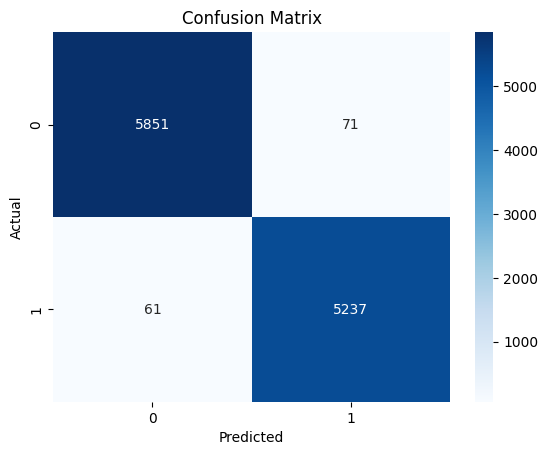

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, prediction_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
report = classification_report(y_test, prediction_lr, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report


,precision,recall,f1-score,support
0,0.989682,0.988011,0.988846,5922.000000
1,0.986624,0.988486,0.987554,5298.000000
accuracy,0.988235,0.988235,0.988235,0.988235
macro avg,0.988153,0.988249,0.988200,11220.000000
weighted avg,0.988238,0.988235,0.988236,11220.000000


In [ ]:
#DT
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier()
DT.fit(xv_train, y_train)

DecisionTreeClassifier()

In [ ]:
pred_dt = DT.predict(xv_test)

In [ ]:
DT.score(xv_test, y_test)

0.995632798573975

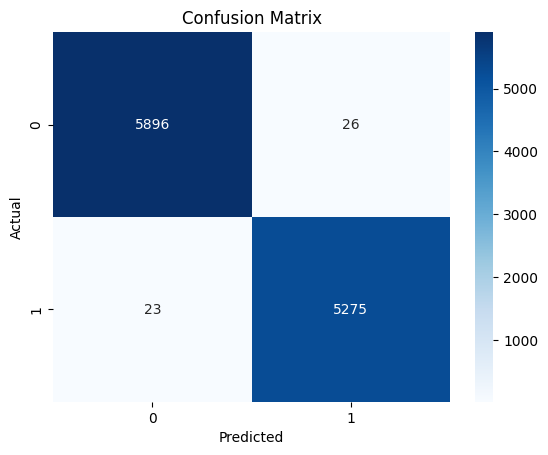

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_dt)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
report = classification_report(y_test, pred_dt, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0,0.996114,0.995610,0.995862,5922.000000
1,0.995095,0.995659,0.995377,5298.000000
accuracy,0.995633,0.995633,0.995633,0.995633
macro avg,0.995605,0.995634,0.995619,11220.000000
weighted avg,0.995633,0.995633,0.995633,11220.000000


In [ ]:
#GBC
from sklearn.ensemble import GradientBoostingClassifier
GBC = GradientBoostingClassifier(random_state=0)
GBC.fit(xv_train, y_train)

GradientBoostingClassifier(random_state=0)

In [ ]:
gbc_pred = GBC.predict(xv_test)

In [ ]:
GBC.score(xv_test, y_test)

0.9946524064171123

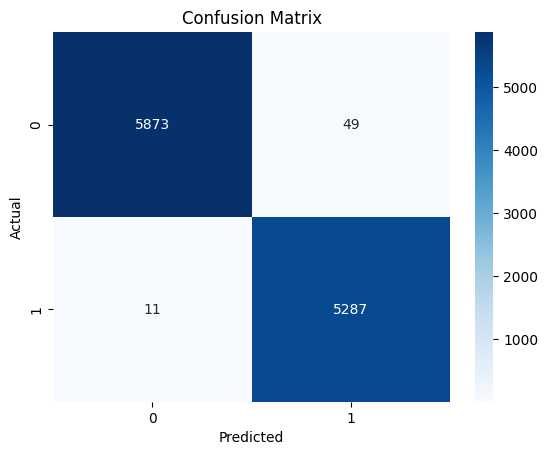

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, gbc_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
report = classification_report(y_test, gbc_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0,0.998131,0.991726,0.994918,5922.000000
1,0.990817,0.997924,0.994358,5298.000000
accuracy,0.994652,0.994652,0.994652,0.994652
macro avg,0.994474,0.994825,0.994638,11220.000000
weighted avg,0.994677,0.994652,0.994653,11220.000000


In [ ]:
#Rf
from sklearn.ensemble import RandomForestClassifier
RF = RandomForestClassifier(random_state=0)
RF.fit(xv_train, y_train)

RandomForestClassifier(random_state=0)

In [ ]:
pred_rf = RF.predict(xv_test)

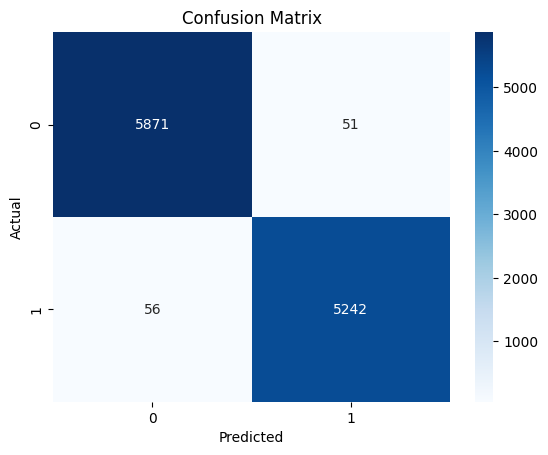

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
report = classification_report(y_test, pred_rf, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report

,precision,recall,f1-score,support
0,0.990552,0.991388,0.990970,5922.000000
1,0.990365,0.989430,0.989897,5298.000000
accuracy,0.990463,0.990463,0.990463,0.990463
macro avg,0.990458,0.990409,0.990433,11220.000000
weighted avg,0.990463,0.990463,0.990463,11220.000000


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

models = {
    "Logistic Regression": prediction_lr,
    "Decision Tree": pred_dt,
    "Gradient Boosting": gbc_pred,
    "Random Forest": pred_rf
}

all_reports = []

for model_name, preds in models.items():
    report = classification_report(y_test, preds, output_dict=True)
    df = pd.DataFrame(report).transpose()
    df["model"] = model_name
    all_reports.append(df)


final_report = pd.concat(all_reports)

final_report


,precision,recall,f1-score,support,model
0,0.989682,0.988011,0.988846,5922.000000,Logistic Regression
1,0.986624,0.988486,0.987554,5298.000000,Logistic Regression
accuracy,0.988235,0.988235,0.988235,0.988235,Logistic Regression
macro avg,0.988153,0.988249,0.988200,11220.000000,Logistic Regression
weighted avg,0.988238,0.988235,0.988236,11220.000000,Logistic Regression
0,0.996114,0.995610,0.995862,5922.000000,Decision Tree
1,0.995095,0.995659,0.995377,5298.000000,Decision Tree
accuracy,0.995633,0.995633,0.995633,0.995633,Decision Tree
macro avg,0.995605,0.995634,0.995619,11220.000000,Decision Tree
weighted avg,0.995633,0.995633,0.995633,11220.000000,Decision Tree


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

models = {
    "Logistic Regression": prediction_lr,
    "Decision Tree": pred_dt,
    "Gradient Boosting": gbc_pred,
    "Random Forest": pred_rf
}

rows = []

for model_name, preds in models.items():
    report = classification_report(y_test, preds, output_dict=True)

    rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-Score": report["weighted avg"]["f1-score"]
    })


final_table = pd.DataFrame(rows)
final_table


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.988235,0.988238,0.988235,0.988236
1,Decision Tree,0.995633,0.995633,0.995633,0.995633
2,Gradient Boosting,0.994652,0.994677,0.994652,0.994653
3,Random Forest,0.990463,0.990463,0.990463,0.990463


In [ ]:
import pickle

saved_models = {
    'Logistic Regression': LR,
    'Decision Tree': DT,
    'Gradient Boosting': GBC,
    'Random Forest': RF
}


with open('FakeNewsModels.pkl', 'wb') as model_file:
    pickle.dump(saved_models, model_file)


with open('fakenews_vectorizer.pkl', 'wb') as vec_file:
    pickle.dump(vectorization, vec_file)

print("✅ All models saved to FakeNewsModels.pkl")
print("✅ TF-IDF Vectorizer saved to fakenews_vectorizer.pkl")


✅ All models saved to FakeNewsModels.pkl
✅ TF-IDF Vectorizer saved to fakenews_vectorizer.pkl
